# SelectOmics, Synthetic Benchmark  v2.0
### Omics-Regime Edition

Evaluates SelectOmics against standard feature-selection methods on synthetic datasets
calibrated to the **small-n / large-p** regime of real processed omics data.

**Target market** (where SelectOmics is designed to operate):

| Axis | Target regime |
|------|---------------|
| Sample size (n) | 50 – 200  (clinical cohort / pilot study) |
| Dimensionality (p) | 500 – 10 000  (post-QC genomics / proteomics) |
| Signal density | 0.1 % – 2 % informative features |
| Within-block correlation (rho) | 0.70 – 0.92  (gene-pathway co-expression) |
| Class imbalance | balanced  ->  85 / 15  (rare-disease case/control) |

Two **adversarial** scenarios (n=500 p=200 and n=800 p=300) are included deliberately -
they represent the LASSO-favourable regime where SelectOmics is *not* expected to win.
These scenarios test whether the benchmark is honest, not whether SelectOmics is best overall.

**Three pre-declared primary evaluation axes:**
1. **Ground-truth recovery**, F1 / Precision / Recall / Jaccard vs. known informative set
2. **Stability**, Kuncheva Stability Index across independent seeds
3. **Downstream performance**, held-out AUC using only selected features

Statistical testing: Friedman  ->  pairwise Wilcoxon signed-rank (Holm-Bonferroni)  ->  Cliff's delta

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print   # fallback when not running inside Jupyter

# ── Path setup ─────────────────────────────────────────────────────────────
# Notebook lives at:  package/benchmarks/Benchmark_Synthetic.ipynb
# os.path.abspath('') reliably returns the notebook's own directory at runtime.
_HERE        = Path(os.path.abspath('')).resolve()   # .../benchmarks/
_PACKAGE_DIR = _HERE.parents[0]                       # .../package/

for _p in [str(_HERE), str(_PACKAGE_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# benchmark_synthetic.py lives in the same directory as this notebook.
from benchmark_synthetic import (
    BENCHMARK_SPEC,
    DEVELOPMENT_SCENARIOS,
    HOLDOUT_SCENARIOS,
    OmicsScenario,
    SCENARIOS,
    SelectOmicsMultiStepSelector,
    SyntheticBenchmark,
    _BORUTA_AVAILABLE,
    _SHAP_AVAILABLE,
    _SO_AVAILABLE,
    friedman_test,
    pairwise_vs_reference,
)

print(f'Notebook dir : {_HERE}')
print(f'Package dir  : {_PACKAGE_DIR}')
print(f'SelectOmics  : {_SO_AVAILABLE}')
print(f'SHAP         : {_SHAP_AVAILABLE}')
print(f'Boruta       : {_BORUTA_AVAILABLE}')

Notebook dir : C:\Users\amaxi\Documents\SelectOmics\package\benchmarks
Package dir  : C:\Users\amaxi\Documents\SelectOmics\package
SelectOmics  : True
SHAP         : True
Boruta       : False


---
## 0.  Pre-Registration  (Locked Benchmark Specification)

The `BENCHMARK_SPEC` dict is defined at module level **before any data is run**.  
It declares all scenarios, primary metrics, seeds, and statistical tests.  
Changing any entry after reviewing results constitutes p-hacking and invalidates the benchmark.

In [2]:
print('=' * 64)
print('BENCHMARK SPECIFICATION  (LOCKED -- declared before first run)')
print('=' * 64)
print(json.dumps(BENCHMARK_SPEC, indent=2, default=str))

BENCHMARK SPECIFICATION  (LOCKED -- declared before first run)
{
  "schema_version": "2.0",
  "locked": true,
  "primary_metrics": {
    "ground_truth_recovery": "f1",
    "stability": "kuncheva_stability",
    "downstream_performance": "test_auc"
  },
  "secondary_metrics": [
    "precision",
    "recall",
    "jaccard",
    "n_selected",
    "reduction_ratio",
    "mean_feature_corr"
  ],
  "seeds": [
    0,
    1,
    2,
    3,
    4
  ],
  "test_size": 0.25,
  "statistical_test": "friedman_then_wilcoxon_signed_rank_paired",
  "correction": "holm_bonferroni",
  "effect_size_metric": "cliffs_delta",
  "alpha": 0.05,
  "data_regime": "small_n_large_p_omics_n50-200_p500-10000",
  "development_scenarios": [
    "omics_standard",
    "omics_tiny_n",
    "omics_high_dim",
    "omics_imbalanced",
    "omics_genomics",
    "adversarial_easy",
    "omics_lowcorr",
    "omics_imbalanced_std",
    "null_control",
    "omics_interaction",
    "omics_multiclass"
  ],
  "holdout_scenarios": [
   

---
## 1.  Configuration

| Setting | `FAST_MODE=True` | `FAST_MODE=False` |
|---------|-----------------|-------------------|
| n_seeds | 3 | 5 |
| SO n_consensus_models | 3 | 5 |
| SO quick_tune_iterations | 10 | 30 |
| SO Step 3 (RFECV wrapper) | disabled | enabled |
| Typical runtime | 1 – 3 h | 6 – 12 h |

Set `RERUN = False` to reload a previously saved `benchmark_raw.csv` instead of rerunning.

In [3]:
# ── EDIT ──────────────────────────────────────────────────────────────────
FAST_MODE        = True    # True = faster settings;  False = full power
SKIP_SELECTOMICS = False   # True = run comparators only (dev iteration)
RERUN            = True    # False = reload saved benchmark_raw.csv
OUTPUT_DIR       = Path('results')
# ─────────────────────────────────────────────────────────────────────────

bm = SyntheticBenchmark(
    output_dir=OUTPUT_DIR,
    fast_mode=FAST_MODE,
    skip_selectomics=SKIP_SELECTOMICS,
)
print(f'Methods registered : {bm.method_names}')
print(f'Seeds per trial    : {bm.n_seeds}  (first {bm.n_seeds} of BENCHMARK_SPEC["seeds"])')

Methods registered : ['VarCorr_Baseline', 'LASSO', 'ElasticNet', 'RFECV', 'RF_Importance', 'PermImportance', 'SHAP', 'SO_S1->2', 'SelectOmics', 'SO_S1_only', 'SO_S2_only', 'SO_S3_only']
Seeds per trial    : 3  (first 3 of BENCHMARK_SPEC["seeds"])


---
## 2.  Scenarios

**Development** (6 scenarios, yellow highlight = holdout):  used freely during iteration.  
**Holdout** (2 scenarios, highlighted):  run **exactly once**, see Section 11.

In [4]:
sc_df = pd.DataFrame([
    {
        'name'          : s.name,
        'split'         : s.split,
        'n'             : s.n_samples,
        'p'             : s.n_features,
        'n_informative' : s.n_informative,
        'signal_%'      : f'{s.signal_density * 100:.2f}',
        'block_size'    : s.block_size,
        'rho'           : s.within_block_corr,
        'imbalance'     : s.class_imbalance,
        'sig_strength'  : s.signal_strength,
        'description'   : s.description,
    }
    for s in SCENARIOS
])

def _row_style(row):
    bg = '#fff3cd' if row['split'] == 'holdout' else ''
    return [f'background-color: {bg}'] * len(row)

sc_df.style.apply(_row_style, axis=1)

,name,split,n,p,n_informative,signal_%,block_size,rho,imbalance,sig_strength,description
0,omics_standard,development,100,2000,10,0.50,20,0.700000,0.500000,1.000000,n=100 * p=2000 * 10 informative (0.5%) * rho=0.70 * balanced
1,omics_tiny_n,development,50,500,10,2.00,20,0.700000,0.500000,1.200000,n=50 * p=500 * 10 informative * rho=0.70 * balanced
2,omics_high_dim,development,100,5000,5,0.10,20,0.800000,0.500000,1.000000,n=100 * p=5000 * 5 informative (0.1%) * rho=0.80 * balanced
3,omics_imbalanced,development,200,1000,15,1.50,20,0.700000,0.150000,1.000000,n=200 * p=1000 * 15 informative * rho=0.70 * 85/15
4,omics_genomics,development,200,10000,10,0.10,50,0.700000,0.500000,1.000000,n=200 * p=10000 * 10 informative (0.1%) * rho=0.70 * balanced
5,adversarial_easy,development,500,200,20,10.00,10,0.100000,0.500000,2.000000,n=500 * p=200 * 20 informative * rho=0.10 * strong signal -- LASSO regime
6,omics_lowcorr,development,100,2000,10,0.50,20,0.100000,0.500000,1.000000,omics_standard with rho=0.10 -- isolates correlation from n/p and signal
7,omics_imbalanced_std,development,100,2000,10,0.50,20,0.700000,0.150000,1.000000,omics_standard at 85/15 -- isolates imbalance from shape
8,null_control,development,100,2000,0,0.00,20,0.700000,0.500000,0.000000,n=100 * p=2000 * NO signal -- every selected feature is a false positive
9,omics_interaction,development,200,2000,10,0.50,20,0.700000,0.500000,1.500000,n=200 * p=2000 * 10 informative in 5 pairs * 60% of signal from interaction


---
## 3.  Run Benchmark  (Development Scenarios)

Results are auto-saved to `results/benchmark_raw.csv` and `results/benchmark_summary.xlsx`.  
Progress is printed as each trial completes.

In [5]:
if RERUN:
    df_raw = bm.run(scenarios=DEVELOPMENT_SCENARIOS)
else:
    _csv = OUTPUT_DIR / 'benchmark_raw.csv'
    if not _csv.exists():
        raise FileNotFoundError(
            f'No saved results at {_csv}.\n'
            f'Set RERUN=True to run the benchmark first.'
        )
    df_raw = bm.load_results(str(_csv))

df_summ = bm.summarise()
print(f'\nRaw rows     : {len(df_raw)}')
print(f'Summary rows : {len(df_summ)}')

Benchmark v2.0  |  11 scenarios x 9 methods (+ 3 ablation on 2 fast scenarios) x 3 seeds = 315 trials

-- omics_standard  [n=100 * p=2000 * 10 informative (0.5%) * rho=0.70 * balanced]
   VarCorr_Baseline        seed=0  n_sel=1000  F1=0.018  AUC=1.000  (0.4s)
   VarCorr_Baseline        seed=1  n_sel=1000  F1=0.016  AUC=0.987  (0.1s)
   VarCorr_Baseline        seed=2  n_sel=1000  F1=0.012  AUC=1.000  (0.1s)
   LASSO                   seed=0  n_sel=  19  F1=0.690  AUC=1.000  (1.6s)
   LASSO                   seed=1  n_sel=  24  F1=0.529  AUC=0.987  (1.6s)
   LASSO                   seed=2  n_sel=  16  F1=0.769  AUC=1.000  (1.6s)
   ElasticNet              seed=0  n_sel=  94  F1=0.192  AUC=1.000  (0.8s)
   ElasticNet              seed=1  n_sel= 102  F1=0.179  AUC=0.987  (0.8s)
   ElasticNet              seed=2  n_sel= 100  F1=0.182  AUC=1.000  (0.8s)
   RFECV                   seed=0  n_sel=  20  F1=0.600  AUC=1.000  (5.7s)
   RFECV                   seed=1  n_sel=  20  F1=0.533  AUC=0.98

PermImportance: no feature had positive permutation importance. Returning an empty selection rather than the full input.


   PermImportance          seed=2  n_sel=   0  F1=0.000  AUC=nan  (14.8s)
   SHAP                    seed=0  n_sel=  12  F1=0.818  AUC=1.000  (0.2s)
   SHAP                    seed=1  n_sel=  12  F1=0.727  AUC=0.981  (0.2s)
   SHAP                    seed=2  n_sel=  16  F1=0.538  AUC=1.000  (0.2s)


SO config on omics_standard seed=0: step3 requested but skipped (too few features reached it). This configuration is therefore identical to the one without step3, so any ablation difference is zero by construction, not by measurement.


   SO_S1->2                seed=0  n_sel=   7  F1=0.824  AUC=1.000  (40.6s)
   SelectOmics             seed=0  n_sel=   7  F1=0.824  AUC=1.000  (42.3s)


...

   SO_S1->2                seed=2  n_sel=  10  F1=1.000  AUC=0.990  (81.0s)
   SelectOmics             seed=2  n_sel=  10  F1=1.000  AUC=0.990  (81.4s)

-- omics_multiclass  [n=200 * p=2000 * 12 informative * 4 balanced classes * macro-OVR]
   VarCorr_Baseline        seed=0  n_sel=1000  F1=0.016  AUC=0.962  (1.6s)
   VarCorr_Baseline        seed=1  n_sel=1000  F1=0.008  AUC=0.802  (1.8s)
   VarCorr_Baseline        seed=2  n_sel=1000  F1=0.018  AUC=0.973  (1.5s)
   LASSO                   seed=0  n_sel=  57  F1=0.348  AUC=0.978  (8.4s)
   LASSO                   seed=1  n_sel=  47  F1=0.407  AUC=0.983  (8.3s)
   LASSO                   seed=2  n_sel=  58  F1=0.343  AUC=0.972  (8.1s)
   ElasticNet              seed=0  n_sel= 294  F1=0.078  AUC=0.989  (6.2s)
   ElasticNet              seed=1  n_sel= 294  F1=0.078  AUC=0.974  (6.5s)
   ElasticNet              seed=2  n_sel= 285  F1=0.081  AUC=0.957  (5.6s)
   RFECV                   seed=0  n_sel= 100  F1=0.179  AUC=0.971  (69.2s)
   RFECV

SO config on omics_multiclass seed=0: step3 requested but skipped (too few features reached it). This configuration is therefore identical to the one without step3, so any ablation difference is zero by construction, not by measurement.


   SO_S1->2                seed=0  n_sel=  17  F1=0.759  AUC=0.975  (290.0s)
   SelectOmics             seed=0  n_sel=  17  F1=0.759  AUC=0.975  (290.4s)
   SO_S1->2                seed=1  n_sel=  70  F1=0.293  AUC=0.982  (315.7s)
   SelectOmics             seed=1  n_sel=   9  F1=0.857  AUC=0.972  (441.3s)


SO config on omics_multiclass seed=2: step3 requested but skipped (too few features reached it). This configuration is therefore identical to the one without step3, so any ablation difference is zero by construction, not by measurement.


   SO_S1->2                seed=2  n_sel=  15  F1=0.889  AUC=0.963  (263.4s)
   SelectOmics             seed=2  n_sel=  15  F1=0.889  AUC=0.963  (261.3s)

Saved -> results\benchmark_raw.csv
Summary -> results\benchmark_summary.xlsx

Raw rows     : 315
Summary rows : 105


---
## 4.  Ground-Truth Recovery

How well does each method identify the features that were *actually built into the data*?  
**F1** is the primary metric (declared in `BENCHMARK_SPEC`).  Jaccard is a stricter set-overlap measure.

In [6]:
f1_pivot = bm.rank_methods(metric='f1')
print('Mean F1 score  (MEAN row = average over all development scenarios)')
f1_pivot.style.background_gradient(cmap='viridis', vmin=0, vmax=1, axis=None).format('{:.3f}')

Mean F1 score  (MEAN row = average over all development scenarios)


method,ElasticNet,LASSO,PermImportance,RFECV,RF_Importance,SHAP,SO_S1->2,SO_S1_only,SO_S2_only,SO_S3_only,SelectOmics,VarCorr_Baseline
scenario,,,,,,,,,,,,
adversarial_easy,1.000,0.898,0.153,0.400,0.991,0.864,0.602,0.182,0.602,0.432,0.602,0.333
null_control,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
omics_genomics,0.069,0.130,0.172,0.182,0.017,0.683,0.965,nan,nan,nan,0.965,0.004
omics_high_dim,0.060,0.194,0.333,0.170,0.016,0.368,0.902,nan,nan,nan,0.902,0.003
omics_imbalanced,0.358,0.852,0.162,0.556,0.120,0.628,0.826,nan,nan,nan,0.826,0.039
omics_imbalanced_std,0.184,0.509,0.061,0.422,0.051,0.611,0.598,nan,nan,nan,0.598,0.011
omics_interaction,0.136,0.429,0.232,0.622,0.035,0.605,0.982,nan,nan,nan,0.982,0.005
omics_lowcorr,0.207,0.653,0.121,0.622,0.044,0.736,0.882,nan,nan,nan,0.882,0.015
omics_multiclass,0.079,0.366,0.280,0.190,0.032,0.113,0.647,nan,nan,nan,0.835,0.014


In [7]:
_gt_cols = ['precision', 'recall', 'f1', 'jaccard']
_m = df_raw.groupby('method')[_gt_cols].mean().round(3)
_s = df_raw.groupby('method')[_gt_cols].std().round(3)
gt_table = pd.DataFrame(index=_m.index)
for c in _gt_cols:
    gt_table[c] = _m[c].astype(str) + ' +/- ' + _s[c].astype(str)
print('Ground-truth recovery  (mean +/- std across all development scenarios and seeds)')
gt_table

Ground-truth recovery  (mean +/- std across all development scenarios and seeds)


,precision,recall,f1,jaccard
method,,,,
ElasticNet,0.23 +/- 0.305,1.0 +/- 0.0,0.301 +/- 0.306,0.23 +/- 0.305
LASSO,0.497 +/- 0.348,0.894 +/- 0.134,0.549 +/- 0.267,0.425 +/- 0.265
PermImportance,0.833 +/- 0.379,0.104 +/- 0.068,0.182 +/- 0.111,0.104 +/- 0.068
RFECV,0.432 +/- 0.316,0.734 +/- 0.262,0.419 +/- 0.193,0.283 +/- 0.158
RF_Importance,0.127 +/- 0.297,0.985 +/- 0.035,0.151 +/- 0.288,0.126 +/- 0.292
SHAP,0.554 +/- 0.282,0.813 +/- 0.208,0.58 +/- 0.227,0.441 +/- 0.213
SO_S1->2,0.943 +/- 0.167,0.735 +/- 0.228,0.787 +/- 0.176,0.679 +/- 0.225
SO_S1_only,0.087 +/- 0.015,1.0 +/- 0.0,0.16 +/- 0.026,0.087 +/- 0.015
SO_S2_only,1.0 +/- 0.0,0.467 +/- 0.061,0.634 +/- 0.06,0.467 +/- 0.061


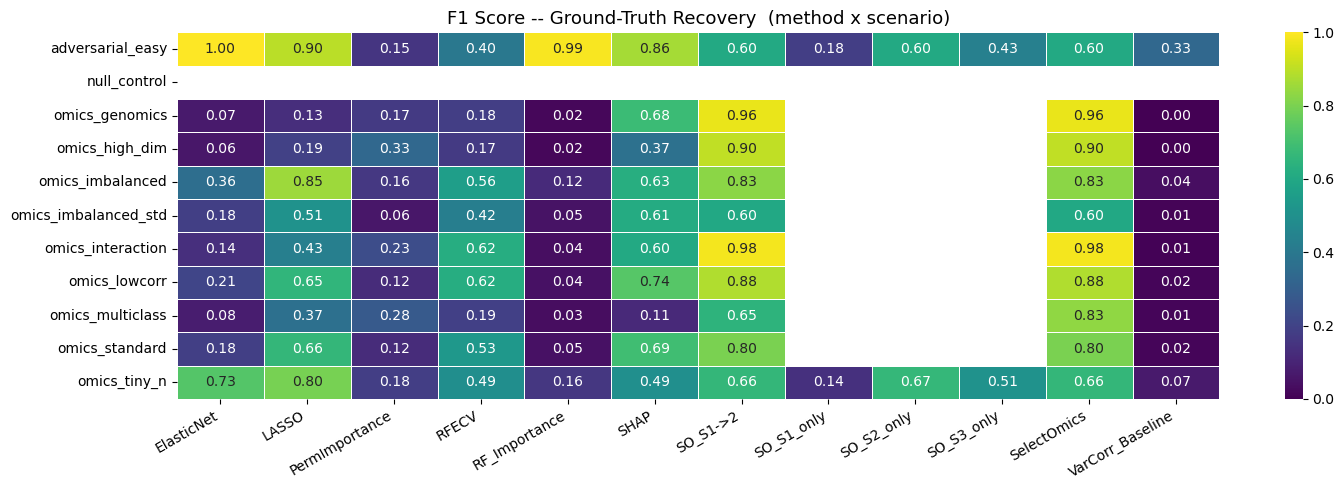

In [8]:
_f1_heat = df_raw.groupby(['scenario', 'method'])['f1'].mean().unstack('method')

fig, ax = plt.subplots(figsize=(max(8, len(bm.method_names) * 1.25), 5))
sns.heatmap(
    _f1_heat, annot=True, fmt='.2f', cmap='viridis',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title('F1 Score -- Ground-Truth Recovery  (method x scenario)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_f1.png', dpi=150)
plt.show()

---
## 5.  Stability  (Kuncheva Stability Index)

KI in [-1, 1].  Values near **1** mean the method selects the same features regardless of
which random seed is used, critical for reproducible omics research.  
KI is the **primary stability metric** declared in `BENCHMARK_SPEC`.

In [9]:
ki_pivot = bm.rank_methods(metric='kuncheva_stability')
print('Kuncheva Stability Index  (KI in [-1, 1],  near 1 = perfectly reproducible)')
ki_pivot.style.background_gradient(cmap='viridis', vmin=-1, vmax=1, axis=None).format('{:.3f}')

Kuncheva Stability Index  (KI in [-1, 1],  near 1 = perfectly reproducible)


method,ElasticNet,LASSO,PermImportance,RFECV,RF_Importance,SHAP,SO_S1->2,SO_S1_only,SO_S2_only,SO_S3_only,SelectOmics,VarCorr_Baseline
scenario,,,,,,,,,,,,
adversarial_easy,1.000,0.777,-0.008,0.316,0.981,0.764,0.362,nan,0.362,0.085,0.362,0.133
null_control,0.007,0.026,nan,0.016,-0.016,0.006,-0.003,nan,nan,nan,-0.003,0.004
omics_genomics,0.042,0.079,0.333,0.811,0.008,0.534,0.928,nan,nan,nan,0.928,0.012
omics_high_dim,0.027,0.105,0.333,0.556,0.004,0.209,0.811,nan,nan,nan,0.811,-0.007
omics_imbalanced,0.244,0.735,-0.001,0.350,0.063,0.454,0.706,nan,nan,nan,0.706,-0.005
omics_imbalanced_std,0.108,0.304,nan,0.495,0.030,0.427,0.382,nan,nan,nan,0.382,0.007
omics_interaction,0.077,0.278,-0.001,0.444,0.014,0.426,0.965,nan,nan,nan,0.965,-0.024
omics_lowcorr,0.105,0.460,-0.000,0.461,0.021,0.554,0.784,nan,nan,nan,0.784,-0.013
omics_multiclass,0.075,0.305,0.266,0.130,0.008,0.111,0.396,nan,nan,nan,0.708,0.001


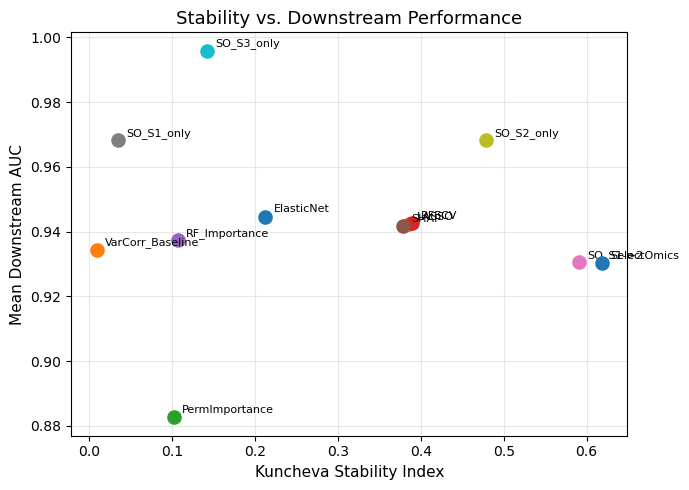

In [10]:
_sc = df_raw.groupby('method')[['kuncheva_stability', 'test_auc']].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in _sc.iterrows():
    ax.scatter(row['kuncheva_stability'], row['test_auc'], s=90, zorder=3)
    ax.annotate(
        row['method'],
        (row['kuncheva_stability'], row['test_auc']),
        textcoords='offset points', xytext=(6, 3), fontsize=8,
    )
ax.set_xlabel('Kuncheva Stability Index', fontsize=11)
ax.set_ylabel('Mean Downstream AUC', fontsize=11)
ax.set_title('Stability vs. Downstream Performance', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter_stability_auc.png', dpi=150)
plt.show()

---
## 6.  Downstream AUC

Each method's selected features feed a fresh `XGBClassifier` trained on the training partition
and evaluated on the held-out test set.  This measures the **real-world predictive value** of
the selected subset, independent of which model was used for selection.  
`test_auc` is the **primary downstream metric** declared in `BENCHMARK_SPEC`.

In [11]:
auc_pivot = bm.rank_methods(metric='test_auc')
print('Downstream AUC  (XGB on selected features only, evaluated on held-out test set)')
auc_pivot.style.background_gradient(cmap='viridis', vmin=0.5, vmax=1.0, axis=None).format('{:.3f}')

Downstream AUC  (XGB on selected features only, evaluated on held-out test set)


method,ElasticNet,LASSO,PermImportance,RFECV,RF_Importance,SHAP,SO_S1->2,SO_S1_only,SO_S2_only,SO_S3_only,SelectOmics,VarCorr_Baseline
scenario,,,,,,,,,,,,
adversarial_easy,1.000,1.000,0.991,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
null_control,0.502,0.483,nan,0.489,0.423,0.472,0.386,nan,nan,nan,0.386,0.502
omics_genomics,0.999,0.999,0.927,0.999,0.999,0.999,0.999,nan,nan,nan,0.999,0.999
omics_high_dim,0.994,0.987,0.916,0.994,0.991,0.994,0.991,nan,nan,nan,0.991,0.996
omics_imbalanced,1.000,1.000,0.919,0.999,1.000,1.000,1.000,nan,nan,nan,1.000,1.000
omics_imbalanced_std,1.000,1.000,0.988,1.000,1.000,1.000,0.984,nan,nan,nan,0.984,1.000
omics_interaction,0.992,0.993,0.869,0.989,0.990,0.989,0.991,nan,nan,nan,0.991,0.937
omics_lowcorr,0.998,1.000,0.832,0.998,0.998,0.998,1.000,nan,nan,nan,1.000,1.000
omics_multiclass,0.973,0.978,0.724,0.972,0.977,0.977,0.973,nan,nan,nan,0.970,0.912


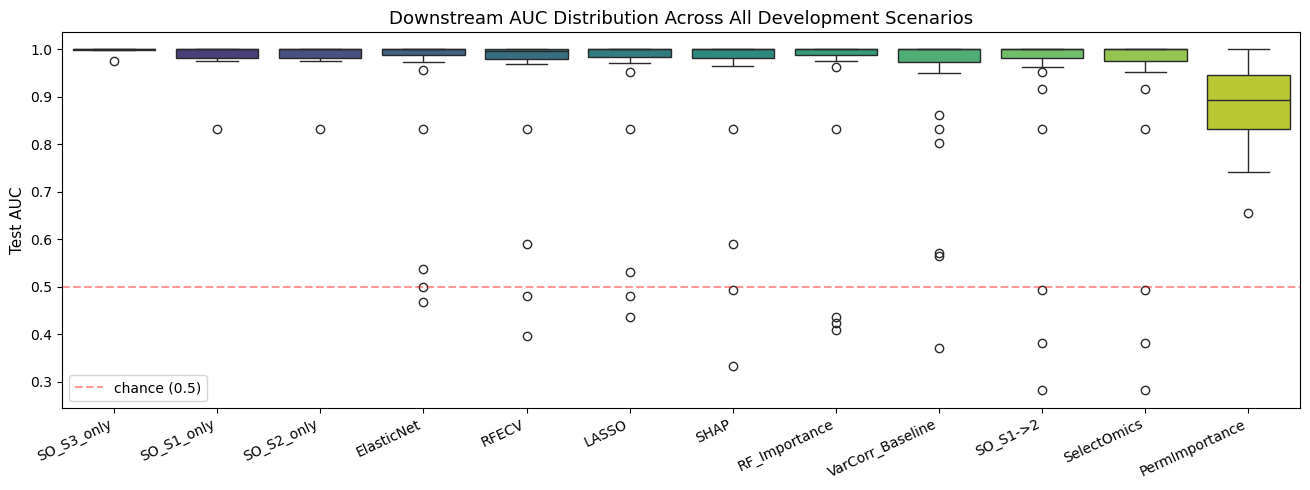

In [12]:
_order_auc = (
    df_raw.groupby('method')['test_auc']
    .mean().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(max(8, len(bm.method_names) * 1.1), 5))
sns.boxplot(
    data=df_raw, x='method', y='test_auc',
    order=_order_auc, palette='viridis', ax=ax,
)
ax.set_title('Downstream AUC Distribution Across All Development Scenarios', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Test AUC', fontsize=11)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='chance (0.5)')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boxplot_auc.png', dpi=150)
plt.show()

---
## 7.  Selection Efficiency

Fewer selected features = a tighter, more interpretable model, *provided performance is maintained*.  
Mean pairwise correlation of selected features measures residual redundancy in the chosen subset.

Selection efficiency  (mean across all development scenarios and seeds)


,Avg features selected,Avg reduction ratio,Avg feature redundancy
method,,,
PermImportance,1.000000,0.999000,0.095000
SelectOmics,8.000000,0.992000,0.427000
SO_S1->2,9.848000,0.991000,0.424000
RFECV,37.273000,0.983000,0.271000
LASSO,38.970000,0.979000,0.271000
SHAP,37.182000,0.975000,0.247000
SO_S2_only,6.833000,0.973000,0.715000
SO_S3_only,12.667000,0.959000,0.386000
ElasticNet,131.515000,0.935000,0.193000


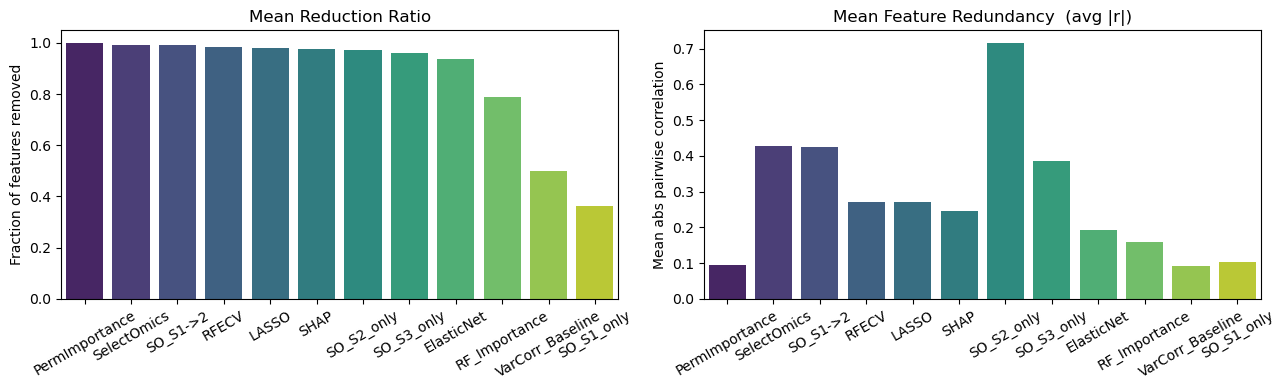

In [ ]:
_eff_cols = ['n_selected', 'reduction_ratio', 'mean_feature_corr']
_eff = df_raw.groupby('method')[_eff_cols].mean().round(3)
_eff.columns = ['Avg features selected', 'Avg reduction ratio', 'Avg feature redundancy']
print('Selection efficiency  (mean across all development scenarios and seeds)')
display(
    _eff.sort_values('Avg reduction ratio', ascending=False)
        .style.background_gradient(cmap='viridis', subset=['Avg reduction ratio'])
)

_ord_eff = (
    df_raw.groupby('method')['reduction_ratio']
    .mean().sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(
    data=df_raw.groupby('method')['reduction_ratio'].mean().reset_index(),
    x='method', y='reduction_ratio', order=_ord_eff,
    palette='viridis', ax=axes[0],
)
axes[0].set_title('Mean Reduction Ratio', fontsize=12)
axes[0].set_ylabel('Fraction of features removed')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(
    data=df_raw.groupby('method')['mean_feature_corr'].mean().reset_index(),
    x='method', y='mean_feature_corr', order=_ord_eff,
    palette='viridis', ax=axes[1],
)
axes[1].set_title('Mean Feature Redundancy  (avg |r|)', fontsize=12)
axes[1].set_ylabel('Mean abs pairwise correlation')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'efficiency.png', dpi=150)
plt.show()

---
## 8.  Computational Cost

In [ ]:
time_df = (
    df_raw.groupby('method')['time_seconds']
    .agg(['mean', 'std', 'max'])
    .round(2)
)
time_df.columns = ['Mean (s)', 'Std (s)', 'Max (s)']
print('Computational cost per (scenario x seed) trial  --  sorted fastest first')
time_df.sort_values('Mean (s)').style.background_gradient(cmap='viridis', subset=['Mean (s)'])

---
## 9.  Statistical Tests

**Protocol** (pre-declared in `BENCHMARK_SPEC`):
1. **Friedman** test across all methods simultaneously (omnibus; detects any difference).
2. **Pairwise Wilcoxon signed-rank** tests vs. SelectOmics as reference, paired by
   `(scenario, seed)`, corrected with **Holm-Bonferroni**.
3. **Cliff's delta** effect size: negligible < 0.147, small < 0.33, medium < 0.474, large >= 0.474.

`favours = 'method'` means the challenger method outperforms SelectOmics on that metric.  
`favours = 'SelectOmics'` means SelectOmics is better.

In [ ]:
_alpha = BENCHMARK_SPEC['alpha']
print('Friedman test across all methods for each primary metric')
print('(non-parametric omnibus;  p < {:.2f} -> at least one method differs significantly)'.format(_alpha))
print()

for _axis, _metric in BENCHMARK_SPEC['primary_metrics'].items():
    _res = friedman_test(df_raw, _metric)
    _sig = '  SIGNIFICANT' if _res['p_value'] < _alpha else '  not significant'
    _note = '  [{}]'.format(_res.get('note', '')) if 'note' in _res else ''
    print(
        f'  {_axis:32s}  metric={_metric:24s}'
        f'  chi2={_res["statistic"]:7.3f}  p={_res["p_value"]:.5f}'
        f'{_sig}{_note}'
    )

In [ ]:
if not _SO_AVAILABLE or ('SelectOmics' not in df_raw['method'].values):
    print('SelectOmics not in results -- pairwise tests vs SelectOmics skipped.')
else:
    print('Pairwise Wilcoxon signed-rank  vs  SelectOmics  (Holm-Bonferroni corrected)')
    print()
    for _axis, _metric in BENCHMARK_SPEC['primary_metrics'].items():
        _pwt = pairwise_vs_reference(
            df_raw, _metric,
            reference='SelectOmics',
            alpha=_alpha,
            higher_is_better=True,   # all primary metrics are higher-is-better
        )
        print(f'\n-- {_axis}  (metric: {_metric}) --')
        if _pwt.empty:
            print('   (no pairwise results)')
        else:
            display(
                _pwt[['method', 'n_pairs', 'W_statistic', 'p_raw',
                       'p_corrected', 'significant', 'cliff_delta',
                       'effect_size', 'favours']]
            )

---
## 10.  Overall Method Ranking

Composite score: each **quality** metric is rank-normalised to [0, 1] and averaged.  
Higher = better overall.  **This is a summary view, not the primary analysis.**

> Runtime (`time_seconds`) is deliberately excluded from this composite.  
> SelectOmics is a thoroughness-first pipeline, including wall-clock time would conflate  
> selection quality with computational budget.  See Section 8 for the full runtime table.

In [ ]:
# Quality metrics only, time_seconds excluded (reported separately in Section 8).
# Including runtime would penalise thoroughness-first methods like SelectOmics.
_metrics_hib = ['f1', 'jaccard', 'test_auc', 'kuncheva_stability', 'reduction_ratio']
_metrics_lib = ['mean_feature_corr']   # lower is better

_all_metrics = [m for m in _metrics_hib + _metrics_lib if m in df_raw.columns]
_method_means = df_raw.groupby('method')[_all_metrics].mean()

ranked = pd.DataFrame(index=_method_means.index)
for m in _metrics_hib:
    if m not in _method_means.columns:
        continue
    col = _method_means[m]
    rng = (col.max() - col.min()) or 1e-9
    ranked[m] = (col - col.min()) / rng
for m in _metrics_lib:
    if m not in _method_means.columns:
        continue
    col = _method_means[m]
    rng = (col.max() - col.min()) or 1e-9
    ranked[m] = 1.0 - (col - col.min()) / rng

ranked['composite_score'] = ranked.mean(axis=1)
print('Composite ranking  (rank-normalised per quality metric, averaged;  higher = better overall)')
print('Runtime excluded, see Section 8 for computational cost.')
ranked.sort_values('composite_score', ascending=False).round(3).style.background_gradient(
    cmap='viridis', subset=['composite_score'], axis=0
)

In [ ]:
_r_metrics = ['f1', 'test_auc', 'kuncheva_stability', 'reduction_ratio', 'jaccard']
_r_labels  = ['F1', 'AUC', 'Stability', 'Reduction', 'Jaccard']
_r_n       = len(_r_metrics)
_angles    = np.linspace(0, 2 * np.pi, _r_n, endpoint=False).tolist()
_angles   += _angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
_colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(ranked)))

for (method, row), colour in zip(ranked.iterrows(), _colours):
    if not all(m in row.index for m in _r_metrics):
        continue
    vals = [row[m] for m in _r_metrics] + [row[_r_metrics[0]]]
    ax.plot(_angles, vals, 'o-', linewidth=1.5, label=method, color=colour)
    ax.fill(_angles, vals, alpha=0.05, color=colour)

ax.set_xticks(_angles[:-1])
ax.set_xticklabels(_r_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
ax.set_title('Method Profiles  (rank-normalised per metric)', fontsize=13, pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radar_methods.png', dpi=150)
plt.show()

In [ ]:
_xlsx = OUTPUT_DIR / 'benchmark_full.xlsx'
with pd.ExcelWriter(_xlsx) as writer:
    df_raw.to_excel(writer,    sheet_name='Raw',           index=False)
    df_summ.to_excel(writer,   sheet_name='Summary',       index=False)
    f1_pivot.to_excel(writer,  sheet_name='F1_pivot')
    auc_pivot.to_excel(writer, sheet_name='AUC_pivot')
    ki_pivot.to_excel(writer,  sheet_name='KI_pivot')
    ranked.to_excel(writer,    sheet_name='Composite_rank')
    time_df.to_excel(writer,   sheet_name='Runtime')
print(f'Full development results -> {_xlsx}')

---
## 11.  SelectOmics Step Decomposition

Runs SelectOmics in multiple independent pipeline configurations to give
**fair, same-input comparisons** against each standalone method.

### Primary analysis, cumulative configs (all scenarios)

Each config starts from the **raw feature matrix** and applies an increasing
prefix of the pipeline, so comparisons within each group are fair:

| SO method | Steps enabled | Comparable standalone | What it tests |
|---|---|---|---|
| `SO_S1->2` | 1+2 | `LASSO`, `ElasticNet` | Does filter+regularise beat regularise alone? |
| `SelectOmics` | 1+2+3 | `RFECV` | Does the full pre-processing pipeline beat RFECV alone? |
| `SelectOmics` | 1+2+3 |, | End-to-end pipeline |

### Diagnostic / ablation, isolated configs (fast scenarios only)

Each config enables **exactly one step** on the raw feature matrix.
Useful for diagnosing which SO techniques outperform their standalone equivalents.
> ⚠️ Isolated SO steps were not designed to run without the preceding pipeline;
> losses here do **not** imply the full pipeline is worse.

| SO method | Step | Comparable standalone |
|---|---|---|
| `SO_S1_only` | 1 only | `VarCorr_Baseline` |
| `SO_S2_only` | 2 only | `LASSO`, `ElasticNet` |
| `SO_S3_only` | 3 only | `RFECV` |


In [ ]:
# -- Check which SO step records are present ---------------------------
_cumul_labels  = SelectOmicsMultiStepSelector.CUMULATIVE_NAMES
_iso_labels    = SelectOmicsMultiStepSelector.ISOLATED_NAMES
_ablation_sc   = SelectOmicsMultiStepSelector.ABLATION_SCENARIOS

_has_cumul = all(m in df_raw['method'].values for m in _cumul_labels)
_has_iso   = all(m in df_raw['method'].values for m in _iso_labels)

if not _has_cumul:
    print('WARNING: cumulative SO records missing. Set RERUN=True and re-run.')
else:
    print(f'Cumulative labels present : {_cumul_labels}')
    print(f'Ablation  labels present  : {_iso_labels} -> {_has_iso}')
    print(f'Ablation scenarios        : {_ablation_sc}')
    print()
    print(df_raw[df_raw['method'].isin(_cumul_labels + _iso_labels)][
        ['scenario', 'method', 'seed', 'n_selected', 'f1', 'test_auc', 'time_seconds']
    ].sort_values(['scenario', 'method', 'seed']).to_string(index=False))

In [ ]:
if _has_cumul:
    # -- Cumulative comparisons (primary analysis) ----------------------
    _CUMUL_GROUPS = [
        ('Filter + Regularise  vs  LASSO / ElasticNet',
         ['SO_S1->2', 'LASSO', 'ElasticNet']),
        ('Filter + Reg + Wrapper  vs  RFECV',
         ['SelectOmics', 'RFECV']),
        ('Full SelectOmics pipeline',
         ['SelectOmics']),
    ]
    _metrics_show = ['f1', 'kuncheva_stability', 'test_auc',
                     'n_selected', 'reduction_ratio']

    print('=== PRIMARY ANALYSIS: Cumulative SO configs (all scenarios) ===')
    for group_label, methods in _CUMUL_GROUPS:
        _sub = (
            df_raw[df_raw['method'].isin(methods)]
            .groupby('method')[_metrics_show].mean()
            .reindex(methods).round(3)
        )
        print(f'\n-- {group_label}')
        display(
            _sub.style
                .background_gradient(cmap='viridis',
                    subset=['f1', 'kuncheva_stability', 'test_auc'], axis=0)
                .format('{:.3f}')
        )

In [ ]:
if _has_cumul:
    # -- Cumulative step bar charts (primary, all scenarios) ------------
    _CUMUL_PLOT_GROUPS = [
        ('SO_S1->2 vs LASSO/ElasticNet', ['SO_S1->2',    'LASSO', 'ElasticNet']),
        ('SelectOmics vs RFECV',          ['SelectOmics', 'RFECV']),
        ('Full pipeline',              ['SelectOmics']),
    ]
    _PLOT_METRICS = [
        ('f1',                 'F1  (ground-truth recovery)', 0,    1),
        ('kuncheva_stability', 'KI  (stability)',            -1,    1),
        ('test_auc',           'AUC  (downstream)',           0.5,  1),
    ]

    _n_rows, _n_cols = len(_PLOT_METRICS), len(_CUMUL_PLOT_GROUPS)
    fig, axes = plt.subplots(_n_rows, _n_cols,
                             figsize=(_n_cols * 3.5, _n_rows * 3.2),
                             sharey='row')

    for ci, (glabel, gmethods) in enumerate(_CUMUL_PLOT_GROUPS):
        for ri, (metric, ylabel, ymin, ymax) in enumerate(_PLOT_METRICS):
            ax  = axes[ri][ci]
            sub = (df_raw[df_raw['method'].isin(gmethods)]
                   .groupby('method')[metric].mean().reindex(gmethods))
            colours = [plt.cm.viridis(x)
                       for x in np.linspace(0.15, 0.85, len(sub))]
            bars = ax.bar(range(len(sub)), sub.values,
                          color=colours, edgecolor='white',
                          linewidth=0.5, width=0.55)
            ax.set_xticks(range(len(sub)))
            ax.set_xticklabels(sub.index.tolist(),
                               rotation=20, ha='right', fontsize=8)
            ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.15)
            ax.set_ylabel(ylabel if ci == 0 else '', fontsize=9)
            if ri == 0:
                ax.set_title(glabel, fontsize=10)
            ax.grid(True, axis='y', alpha=0.3)
            for bar, val in zip(bars, sub.values):
                if val == val:  # skip NaN
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + (ymax - ymin) * 0.02,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=7)

    fig.suptitle('Cumulative SO configs vs standalone methods\n'
                 '(mean over all development scenarios × seeds)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'step_cumulative.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
if _has_iso:
    # -- Isolated / ablation comparisons (fast scenarios only) ----------
    _ISO_GROUPS = [
        ('SO_S1_only vs VarCorr',        ['SO_S1_only', 'VarCorr_Baseline']),
        ('SO_S2_only vs LASSO/ElasticNet',['SO_S2_only', 'LASSO', 'ElasticNet']),
        ('SO_S3_only vs RFECV',           ['SO_S3_only', 'RFECV']),
    ]

    # Filter to ablation scenarios only
    _df_abl = df_raw[df_raw['scenario'].isin(_ablation_sc)]

    print('=== DIAGNOSTIC: Isolated SO steps (ablation scenarios only) ===')
    print(f'Scenarios: {sorted(_ablation_sc)}')
    print('NOTE: isolated steps run on raw data without preceding pipeline.')
    print('      A loss here does not imply the full pipeline is inferior.\n')

    for group_label, methods in _ISO_GROUPS:
        _avail = [m for m in methods if m in _df_abl['method'].values]
        if len(_avail) < 2:
            continue
        _sub = (
            _df_abl[_df_abl['method'].isin(_avail)]
            .groupby('method')[['f1', 'kuncheva_stability', 'test_auc',
                               'n_selected', 'reduction_ratio']].mean()
            .reindex(_avail).round(3)
        )
        print(f'\n-- {group_label}')
        display(
            _sub.style
                .background_gradient(cmap='viridis',
                    subset=['f1', 'kuncheva_stability', 'test_auc'], axis=0)
                .format('{:.3f}')
        )
elif _has_cumul:
    print('Ablation records not present (run only on omics_tiny_n, adversarial_easy).')

In [ ]:
if _has_iso:
    # -- Isolated step bar charts (ablation, fast scenarios) ------------
    _ISO_PLOT_GROUPS = [
        ('SO_S1_only vs VarCorr',         ['SO_S1_only', 'VarCorr_Baseline']),
        ('SO_S2_only vs LASSO/ElasticNet', ['SO_S2_only', 'LASSO', 'ElasticNet']),
        ('SO_S3_only vs RFECV',            ['SO_S3_only', 'RFECV']),
    ]
    _df_abl = df_raw[df_raw['scenario'].isin(_ablation_sc)]

    _n_rows, _n_cols = len(_PLOT_METRICS), len(_ISO_PLOT_GROUPS)
    fig, axes = plt.subplots(_n_rows, _n_cols,
                             figsize=(_n_cols * 3.0, _n_rows * 3.0),
                             sharey='row')

    for ci, (glabel, gmethods) in enumerate(_ISO_PLOT_GROUPS):
        _avail = [m for m in gmethods if m in _df_abl['method'].values]
        for ri, (metric, ylabel, ymin, ymax) in enumerate(_PLOT_METRICS):
            ax  = axes[ri][ci]
            sub = (_df_abl[_df_abl['method'].isin(_avail)]
                   .groupby('method')[metric].mean().reindex(_avail))
            colours = [plt.cm.viridis(x)
                       for x in np.linspace(0.15, 0.85, len(sub))]
            bars = ax.bar(range(len(sub)), sub.values,
                          color=colours, edgecolor='white',
                          linewidth=0.5, width=0.55)
            ax.set_xticks(range(len(sub)))
            ax.set_xticklabels(sub.index.tolist(),
                               rotation=20, ha='right', fontsize=8)
            ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.15)
            ax.set_ylabel(ylabel if ci == 0 else '', fontsize=9)
            if ri == 0:
                ax.set_title(glabel, fontsize=9)
            ax.grid(True, axis='y', alpha=0.3)
            for bar, val in zip(bars, sub.values):
                if val == val:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + (ymax - ymin) * 0.02,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=7)

    fig.suptitle('Diagnostic: isolated SO steps vs standalone methods\n'
                 '(ablation scenarios: omics_tiny_n, adversarial_easy only)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'step_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
if _has_cumul:
    # -- Feature-count progression through the cumulative SO pipeline ---
    _PROG_LABELS = ['SO_S1->2', 'SelectOmics', 'SelectOmics']
    _prog = (
        df_raw[df_raw['method'].isin(_PROG_LABELS)]
        .groupby(['scenario', 'method'])['n_selected']
        .mean().unstack('method')
        .reindex(columns=_PROG_LABELS).round(1)
    )
    _nf = df_raw[df_raw['method'] == 'SO_S1->2'].groupby('scenario')['n_features'].first()
    _prog.insert(0, 'p (total)', _nf)

    print('Mean features selected at each cumulative SO stage:')
    display(
        _prog.style
             .background_gradient(cmap='viridis_r', subset=_PROG_LABELS, axis=None)
             .format('{:.0f}')
    )

    _rr = _prog[_PROG_LABELS].div(_prog['p (total)'], axis=0).round(4)
    _rr.columns = [f'{c} %retained' for c in _PROG_LABELS]
    print('\nFraction of features retained at each stage:')
    display(
        _rr.style
           .background_gradient(cmap='viridis_r', axis=None)
           .format('{:.1%}')
    )

---
## 12.  HOLDOUT EVALUATION

> **WARNING, run this section EXACTLY ONCE.**
>
> The two holdout scenarios (`omics_ultra_sparse`, `adversarial_large_n`) were set aside
> *before any development run was inspected*.  Running them multiple times, peeking at
> intermediate results, or adjusting any setting after the first run constitutes p-hacking
> and invalidates the benchmark.
>
> **Only proceed when all development decisions are final.**

A fresh `SyntheticBenchmark` instance is created so holdout records are stored separately
from the development records and saved to `results/holdout/`.

In [ ]:
# ── HOLDOUT, run once only ────────────────────────────────────────────────
# A fresh instance keeps holdout records isolated from development records.
bm_holdout = SyntheticBenchmark(
    output_dir=OUTPUT_DIR / 'holdout',
    fast_mode=FAST_MODE,
    skip_selectomics=SKIP_SELECTOMICS,
)

# run_holdout() calls run(HOLDOUT_SCENARIOS) which saves to
# holdout/benchmark_raw.csv, then also writes holdout/holdout_raw.csv.
df_holdout = bm_holdout.run_holdout()

In [ ]:
df_summ_holdout = bm_holdout.summarise()

print('Holdout raw results:')
print(
    df_holdout[['scenario', 'method', 'seed', 'f1', 'test_auc',
                'kuncheva_stability', 'n_selected', 'time_seconds']]
    .to_string(index=False)
)
print()

for _metric, _label in [('f1', 'F1'), ('test_auc', 'AUC'), ('kuncheva_stability', 'KI')]:
    _hpivot = (
        df_holdout.groupby(['scenario', 'method'])[_metric]
        .mean().unstack('method').round(3)
    )
    print(f'Holdout {_label}  (mean over {bm_holdout.n_seeds} seeds):')
    display(_hpivot.style.background_gradient(cmap='viridis', axis=None).format('{:.3f}'))
    print()

In [ ]:
_alpha = BENCHMARK_SPEC['alpha']   # re-declared here so this cell runs independently

if ('SelectOmics' not in df_holdout['method'].values):
    print('SelectOmics not in holdout results -- pairwise tests skipped.')
    print('Friedman test (all methods):')
    for _axis, _metric in BENCHMARK_SPEC['primary_metrics'].items():
        _fr = friedman_test(df_holdout, _metric)
        print(f'  {_axis}: chi2={_fr["statistic"]:.3f}  p={_fr["p_value"]:.5f}')
else:
    print('Holdout statistical tests  (Friedman + Wilcoxon vs SelectOmics)')
    print()
    for _axis, _metric in BENCHMARK_SPEC['primary_metrics'].items():
        _fr = friedman_test(df_holdout, _metric)
        _sig = '  SIGNIFICANT' if _fr['p_value'] < _alpha else '  not significant'
        print(
            f'  Friedman  {_axis:32s}  metric={_metric:24s}'
            f'  chi2={_fr["statistic"]:7.3f}  p={_fr["p_value"]:.5f}{_sig}'
        )
        _pwt = pairwise_vs_reference(
            df_holdout, _metric,
            reference='SelectOmics',
            alpha=_alpha,
            higher_is_better=True,
        )
        if not _pwt.empty:
            display(
                _pwt[['method', 'n_pairs', 'p_corrected', 'significant',
                       'cliff_delta', 'effect_size', 'favours']]
            )
        print()

In [ ]:
_holdout_xlsx = OUTPUT_DIR / 'holdout' / 'holdout_full.xlsx'
with pd.ExcelWriter(_holdout_xlsx) as writer:
    df_holdout.to_excel(writer,        sheet_name='Holdout_Raw',     index=False)
    df_summ_holdout.to_excel(writer,   sheet_name='Holdout_Summary', index=False)
print(f'Holdout results -> {_holdout_xlsx}')